In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.resnet import preprocess_input

from IPython.display import display
from sklearn.manifold import TSNE
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras import layers, models, regularizers

import sys
import subprocess
try:
    import keras
    import keras_hub
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "keras", "keras-hub"])
    import keras
    import keras_hub

base_dir = "/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

2026-04-04 23:02:40.431558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775343760.621813      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775343760.680499      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775343761.155655      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775343761.155700      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775343761.155704      25 computation_placer.cc:177] computation placer alr

In [2]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

    print("GPU is active")
    print("Policy:", mixed_precision.global_policy())
else:
    print("No GPU detected by TensorFlow")

GPU is active
Policy: <DTypePolicy "mixed_float16">


# Functions

In [3]:
def _count_images_per_class(split_dir):
    counts = {}

    for label in sorted(os.listdir(split_dir)):
        label_path = os.path.join(split_dir, label)

        if os.path.isdir(label_path):
            n_files = sum(
                1 for f in os.listdir(label_path)
                if os.path.splitext(f)[1].lower() in IMG_EXTENSIONS
            )
            counts[label] = n_files

    return counts

def check_label_distribution(train_dir, test_dir):
    train_counts = _count_images_per_class(train_dir)
    test_counts = _count_images_per_class(test_dir)

    labels = sorted(set(train_counts.keys()) | set(test_counts.keys()))

    df = pd.DataFrame({
        "label": labels,
        "train_count": [train_counts.get(label, 0) for label in labels],
        "test_count": [test_counts.get(label, 0) for label in labels]
    })
    print(f"Number of classes: {len(df)}")
    print()
    train_min_row = df.loc[df["train_count"].idxmin()]
    train_max_row = df.loc[df["train_count"].idxmax()]
    test_min_row = df.loc[df["test_count"].idxmin()]
    test_max_row = df.loc[df["test_count"].idxmax()]
    print(f"Train min: {train_min_row['label']} -> {int(train_min_row['train_count'])}")
    print(f"Train max: {train_max_row['label']} -> {int(train_max_row['train_count'])}")
    print(f"Test min: {test_min_row['label']} -> {int(test_min_row['test_count'])}")
    print(f"Test max: {test_max_row['label']} -> {int(test_max_row['test_count'])}")
    display(df)
    return df

In [4]:
def plot_label_distribution(df):
    plt.figure(figsize=(18, 6))
    plt.bar(df["label"], df["train_count"], alpha=0.7, label="Train")
    plt.bar(df["label"], df["test_count"], alpha=0.7, label="Test")
    plt.xticks(rotation=90)
    plt.title("Label distribution")
    plt.xlabel("Label")
    plt.ylabel("Number of images")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
def create_train_test_generators(train_dir, test_dir, target_size=(224, 224), batch_size=32, seed=42):
    train_datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True
    )
    test_datagen = ImageDataGenerator()
    train_gen = train_datagen.flow_from_directory(
        directory=train_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=True,
        seed=seed
    )
    test_gen = test_datagen.flow_from_directory(
        directory=test_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False
    )
    return train_gen, test_gen

In [6]:
def plot_train_test_curves(history):
    hist = history.history
    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Test Accuracy")
    plt.title("Train vs Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Test Loss")
    plt.title("Train vs Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_tsne_embeddings(df, embedding_col="embedding", label_col="label", sample_size=None, figsize=(12, 8), title="t-SNE of embeddings"):
    plot_df = df.copy()
    if sample_size is not None and sample_size < len(plot_df):
        plot_df = plot_df.sample(sample_size, random_state=42).reset_index(drop=True)
    X = np.vstack(plot_df[embedding_col].values)
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        init="pca",
        learning_rate="auto"
    )
    X_tsne = tsne.fit_transform(X)
    plot_df["tsne_1"] = X_tsne[:, 0]
    plot_df["tsne_2"] = X_tsne[:, 1]
    plt.figure(figsize=figsize)
    for label in sorted(plot_df[label_col].unique()):
        subset = plot_df[plot_df[label_col] == label]
        plt.scatter(
            subset["tsne_1"],
            subset["tsne_2"],
            label=label,
            alpha=0.7,
            s=35
        )
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [7]:
def load_convnext(input_shape=(224, 224, 3), num_classes=2, learning_rate=1e-4, dropout_rate=0.3):
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    base_model = ConvNeXtTiny(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = True
    for layer in base_model.layers[:-10]:
        layer.trainable = False
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=True)
    embedding_output = layers.GlobalAveragePooling2D(name="embedding_layer")(x)
    x = layers.Dropout(dropout_rate)(embedding_output)
    output = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    model = models.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"],
        run_eagerly=False,
        jit_compile=True
    )
    return model

In [8]:
def load_vit(
    input_shape=(224, 224, 3),
    num_classes=2,
    vit_preset="vit_base_patch16_224_imagenet",
    learning_rate=1e-4,
    dropout_rate=0.3,
    weight_decay=1e-4
):
    keras.mixed_precision.set_global_policy("mixed_float16")

    preprocessor = keras_hub.models.ImageClassifierPreprocessor.from_preset(vit_preset)
    backbone = keras_hub.models.Backbone.from_preset(vit_preset)

    backbone.trainable = True
    if len(backbone.layers) > 10:
        for layer in backbone.layers[:-10]:
            layer.trainable = False
    inputs = keras.layers.Input(shape=input_shape, dtype="float32", name="image")
    x = preprocessor(inputs)
    x = backbone(x)
    if isinstance(x, (list, tuple)):
        x = x[0]
    if len(x.shape) == 3:
        x = keras.layers.Lambda(lambda t: t[:, 0], name="cls_token")(x)
    embedding_output = keras.layers.Activation("linear", dtype="float32", name="embedding_layer")(x)
    x = keras.layers.Dropout(dropout_rate)(embedding_output)
    outputs = keras.layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=weight_decay
        ),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"],
        run_eagerly=False,
        jit_compile=False
    )
    return model
    
def train_vit(model, train_gen, test_gen, epochs=60):
    class PrintTrainTestMetrics(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            train_acc = logs.get("accuracy")
            test_acc = logs.get("val_accuracy")
            train_loss = logs.get("loss")
            test_loss = logs.get("val_loss")
            print(
                f"Epoch {epoch + 1}/{epochs} - "
                f"train_acc: {train_acc:.4f} - "
                f"test_acc: {test_acc:.4f} - "
                f"train_loss: {train_loss:.4f} - "
                f"test_loss: {test_loss:.4f}"
            )

    callbacks = [
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy",
            mode="max",
            factor=0.2,
            patience=12,
            verbose=1,
            min_lr=1e-7
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=30,
            restore_best_weights=True,
            verbose=1
        ),
        PrintTrainTestMetrics()
    ]

    history = model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=0
    )
    return history

In [9]:
def train_convnext(model, train_gen, test_gen, epochs=10):
    class PrintTrainTestMetrics(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            train_acc = logs.get("accuracy")
            test_acc = logs.get("val_accuracy")
            train_loss = logs.get("loss")
            test_loss = logs.get("val_loss")

            print(
                f"Epoch {epoch + 1}/{epochs} - "
                f"train_acc: {train_acc:.4f} - "
                f"test_acc: {test_acc:.4f} - "
                f"train_loss: {train_loss:.4f} - "
                f"test_loss: {test_loss:.4f}"
            )

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy",
            mode="max",
            factor=0.2,
            patience=4,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        PrintTrainTestMetrics()
    ]

    history = model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=0
    )

    return history

In [10]:
def create_embedding_generator(data_dir, target_size=(224, 224), batch_size=32):
    datagen = ImageDataGenerator()
    data_gen = datagen.flow_from_directory(
        directory=data_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False
    )
    return data_gen
    
def build_embedding_dataframe(model, data_gen):
    embedding_model = tf.keras.Model(
        inputs=model.input,
        outputs=model.get_layer("embedding_layer").output
    )
    embeddings = embedding_model.predict(data_gen, verbose=1)
    index_to_class = {v: k for k, v in data_gen.class_indices.items()}
    labels = [index_to_class[idx] for idx in data_gen.classes]
    df = pd.DataFrame({
        "image_path": data_gen.filepaths,
        "label": labels,
        "embedding": list(embeddings)
    })
    return df

def build_embedding_dataframe_keras(model, data_gen):
    data_gen.reset()
    embedding_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("embedding_layer").output
    )
    embeddings = embedding_model.predict(data_gen, verbose=1)
    index_to_class = {v: k for k, v in data_gen.class_indices.items()}
    labels = [index_to_class[idx] for idx in data_gen.classes]
    df = pd.DataFrame({
        "image_path": data_gen.filepaths,
        "label": labels,
        "embedding": list(embeddings)
    })
    return df


# Training

## Training Vit

In [11]:
vit_train_gen, vit_test_gen = create_train_test_generators(
    train_dir=train_dir,
    test_dir=test_dir,
    target_size=(224, 224),
    batch_size=32
)

Found 13898 images belonging to 22 classes.
Found 1546 images belonging to 22 classes.


In [12]:
vit_model = load_vit(
    input_shape=(224, 224, 3),
    num_classes=vit_train_gen.num_classes,
    vit_preset="vit_base_patch16_224_imagenet",
    learning_rate=1e-4,
    dropout_rate=0.3,
    weight_decay=1e-4
)

I0000 00:00:1775343804.914647      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [13]:
vit_history = train_vit(
    model=vit_model,
    train_gen=vit_train_gen,
    test_gen=vit_test_gen,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1775343851.515323      82 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch 1/15 - train_acc: 0.4688 - test_acc: 0.6436 - train_loss: 1.9301 - test_loss: 1.3667
Epoch 2/15 - train_acc: 0.6937 - test_acc: 0.6746 - train_loss: 1.2363 - test_loss: 1.2747
Epoch 3/15 - train_acc: 0.8111 - test_acc: 0.7361 - train_loss: 0.9058 - test_loss: 1.1449
Epoch 4/15 - train_acc: 0.8933 - test_acc: 0.7607 - train_loss: 0.6923 - test_loss: 1.0905
Epoch 5/15 - train_acc: 0.9435 - test_acc: 0.7794 - train_loss: 0.5538 - test_loss: 1.0800
Epoch 6/15 - train_acc: 0.9672 - test_acc: 0.7872 - train_loss: 0.4891 - test_loss: 1.0385
Epoch 7/15 - train_acc: 0.9783 - test_acc: 0.7865 - train_loss: 0.4500 - test_loss: 1.0392
Epoch 8/15 - train_acc: 0.9811 - test_acc: 0.8047 - train_loss: 0.4396 - test_loss: 1.0058
Epoch 9/15 - train_acc: 0.9827 - test_acc: 0.7917 - train_loss: 0.4288 - test_loss: 1.0513
Epoch 10/15 - train_acc: 0.9827 - test_acc: 0.7962 - train_loss: 0.4276 - test_loss: 1.0083
Epoch 11/15 - train_acc: 0.9791 - test_acc: 0.7788 - train_loss: 0.4313 - test_loss: 1.11

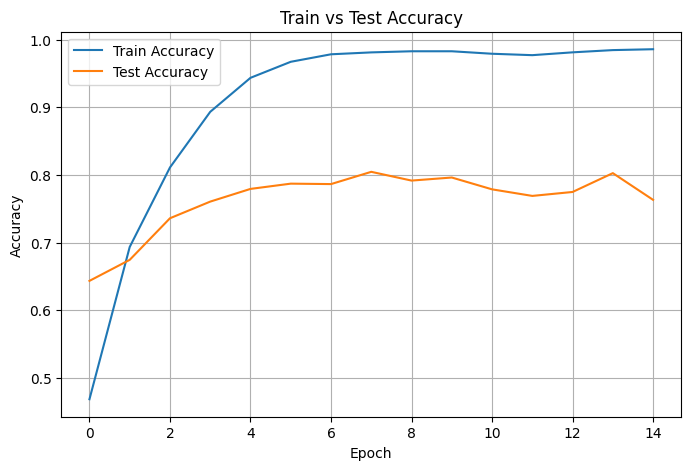

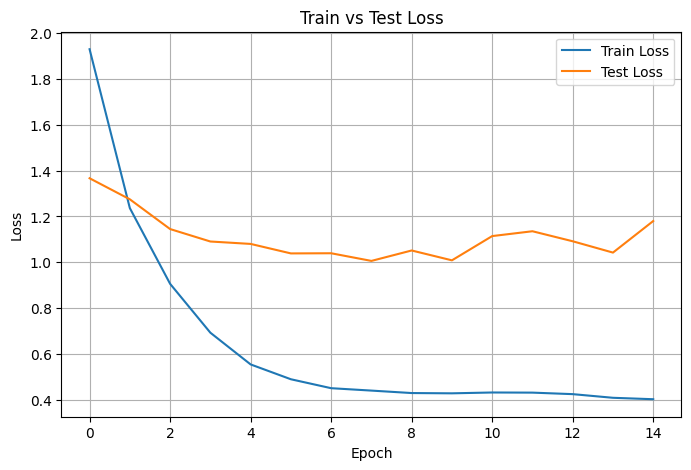

In [14]:
plot_train_test_curves(vit_history)

In [15]:
vit_test_loss, vit_test_acc = vit_model.evaluate(vit_test_gen, verbose=1)
print(f"Final ViT test loss: {vit_test_loss:.4f}")
print(f"Final ViT test accuracy: {vit_test_acc:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 323ms/step - accuracy: 0.8061 - loss: 1.0208
Final ViT test loss: 1.0058
Final ViT test accuracy: 0.8047


In [16]:
vit_train_embed_gen = create_embedding_generator(
    data_dir=train_dir,
    target_size=(224, 224),
    batch_size=32
)

vit_test_embed_gen = create_embedding_generator(
    data_dir=test_dir,
    target_size=(224, 224),
    batch_size=32
)

df_vit_train_embeddings = build_embedding_dataframe_keras(vit_model, vit_train_embed_gen)
df_vit_test_embeddings = build_embedding_dataframe_keras(vit_model, vit_test_embed_gen)

display(df_vit_train_embeddings.head())
display(df_vit_test_embeddings.head())

Found 13898 images belonging to 22 classes.
Found 1546 images belonging to 22 classes.


I0000 00:00:1775349377.050275      84 service.cc:152] XLA service 0x7fea70011820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775349377.050357      84 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  1/435 ━━━━━━━━━━━━━━━━━━━━ 35:55 5s/step

I0000 00:00:1775349380.138038      84 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


435/435 ━━━━━━━━━━━━━━━━━━━━ 105s 231ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 302ms/step


,image_path,label,embedding
0,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.0703125, 0.15551758, -0.2980957, 0.5336914,..."
1,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.3486328, 0.6845703, -0.4819336, 1.0351562, ..."
2,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.2746582, 0.36010742, -0.32177734, 0.6875, 0..."
3,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.5722656, 0.099609375, 0.2310791, 0.4663086,..."
4,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.026351929, -0.7890625, 0.10595703, 0.285644..."


,image_path,label,embedding
0,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[-0.10247803, -0.63134766, -0.17749023, 0.2639..."
1,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.19116211, -0.484375, 0.13061523, -0.0288085..."
2,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.48583984, 0.15441895, -0.0010290146, -0.038..."
3,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.066833496, -0.23718262, 0.23596191, 0.31225..."
4,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.58203125, 0.12322998, 0.9638672, 0.66308594..."


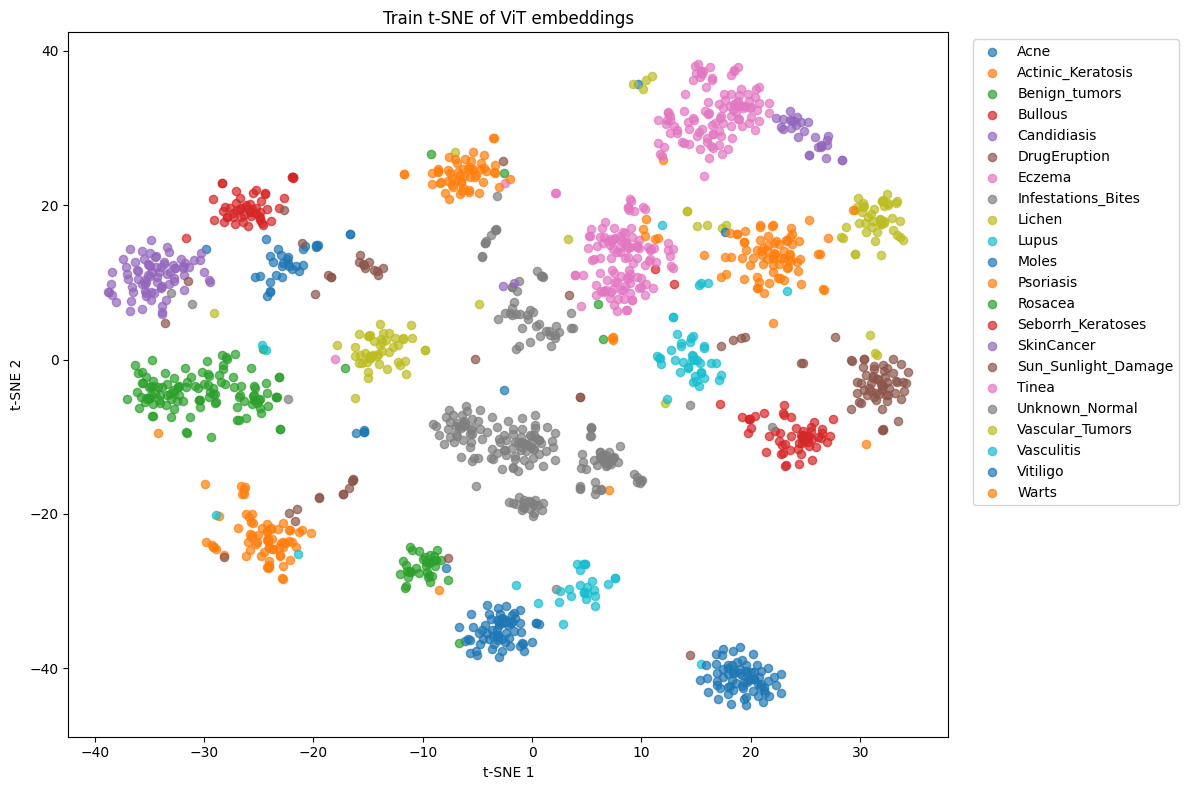

In [17]:
plot_tsne_embeddings(
    df_vit_train_embeddings,
    sample_size=1500,
    title="Train t-SNE of ViT embeddings"
)

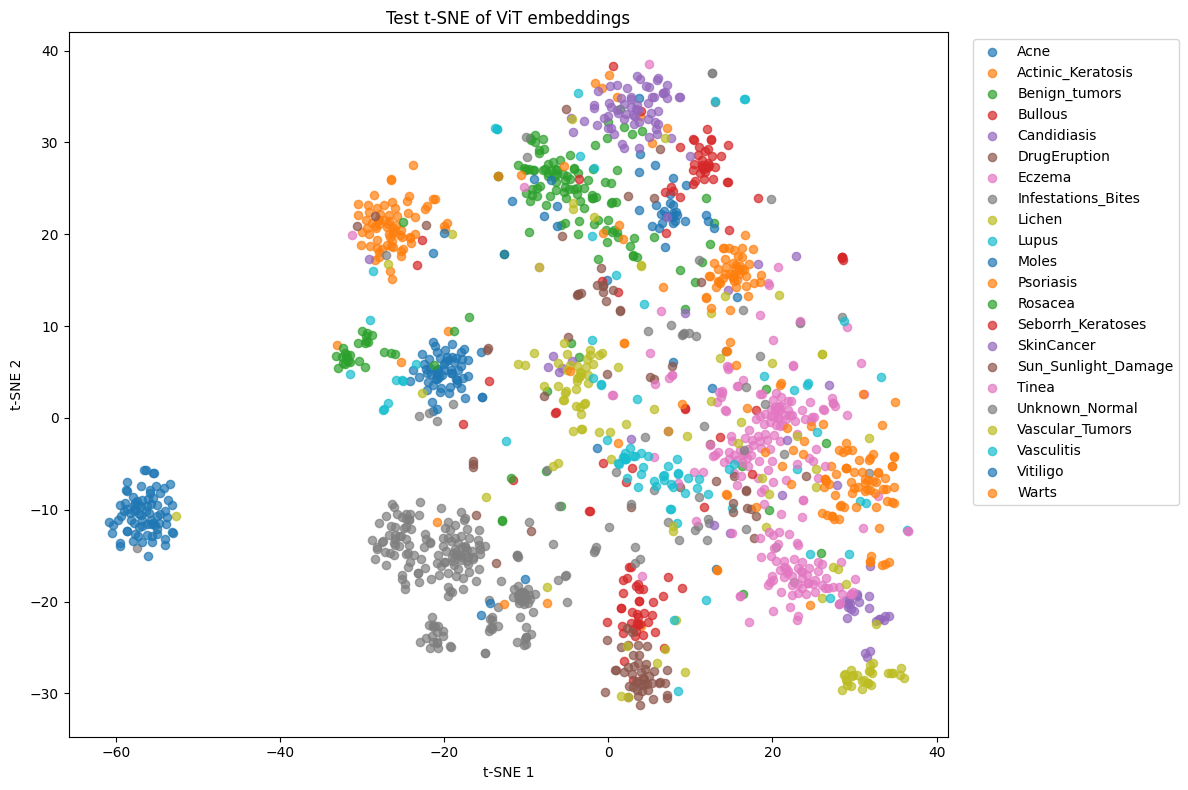

In [18]:
plot_tsne_embeddings(
    df_vit_test_embeddings,
    title="Test t-SNE of ViT embeddings"
)

## Training Convnext

Number of classes: 22

Train min: Candidiasis -> 248
Train max: Unknown_Normal -> 1651
Test min: Candidiasis -> 27
Test max: Unknown_Normal -> 189


,label,train_count,test_count
0,Acne,593,65
1,Actinic_Keratosis,748,83
2,Benign_tumors,1093,121
3,Bullous,504,55
4,Candidiasis,248,27
5,DrugEruption,547,61
6,Eczema,1010,112
7,Infestations_Bites,524,60
8,Lichen,553,61
9,Lupus,311,34


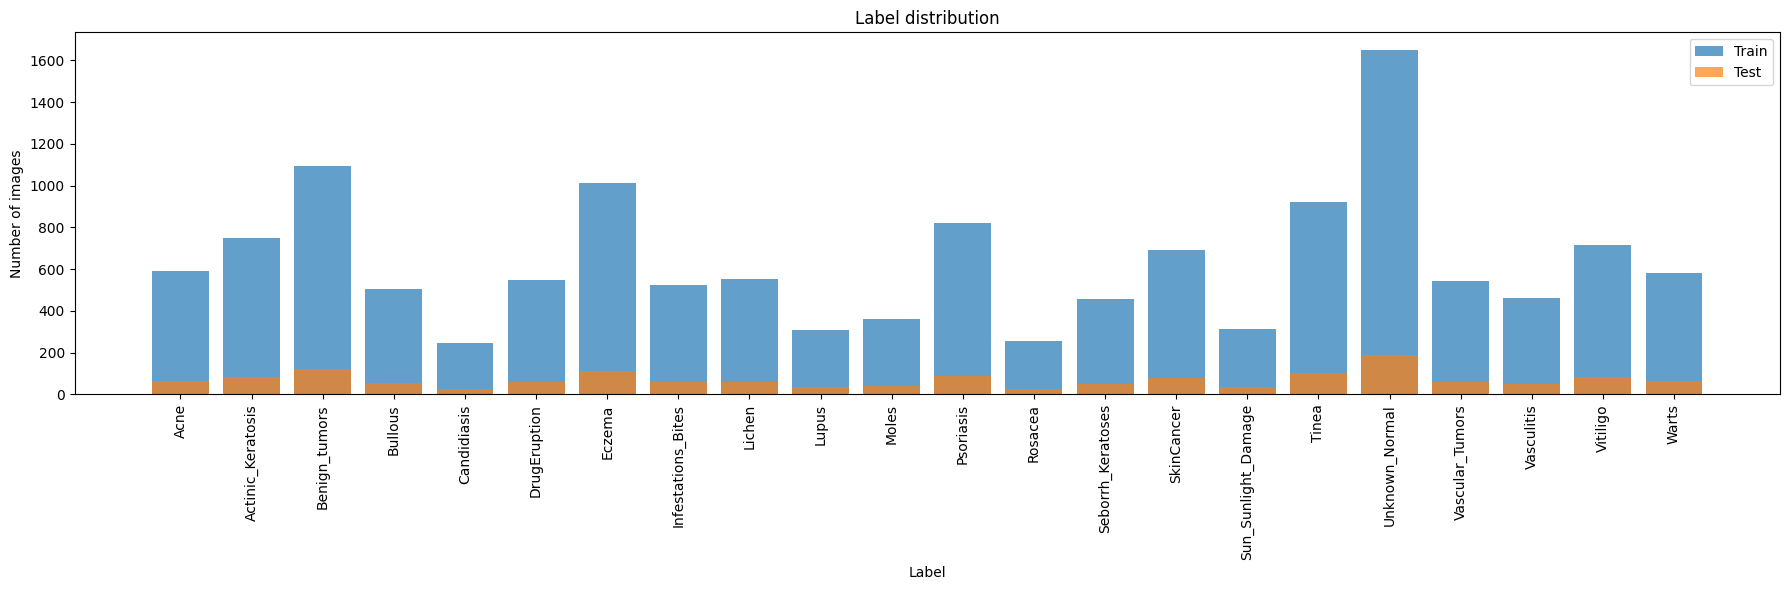

In [19]:
df_distribution = check_label_distribution(train_dir, test_dir)
plot_label_distribution(df_distribution)

In [20]:
train_gen, test_gen = create_train_test_generators(
    train_dir=train_dir,
    test_dir=test_dir,
    target_size=(224, 224),
    batch_size=64
)

Found 13898 images belonging to 22 classes.
Found 1546 images belonging to 22 classes.


In [21]:
model = load_convnext(
    input_shape=(224, 224, 3),
    num_classes=train_gen.num_classes,
    learning_rate=1e-4,
    dropout_rate=0.3
)

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [22]:
history = train_convnext(
    model=model,
    train_gen=train_gen,
    test_gen=test_gen,
    epochs=100
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-04-05 00:38:58.110023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 00:38:58.287556: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 00:38:58.535644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. Th

Epoch 1/100 - train_acc: 0.2469 - test_acc: 0.4004 - train_loss: 2.6234 - test_loss: 2.1102
Epoch 2/100 - train_acc: 0.4382 - test_acc: 0.4690 - train_loss: 1.9938 - test_loss: 1.8992
Epoch 3/100 - train_acc: 0.5015 - test_acc: 0.5026 - train_loss: 1.7963 - test_loss: 1.8065
Epoch 4/100 - train_acc: 0.5463 - test_acc: 0.5162 - train_loss: 1.6676 - test_loss: 1.7506
Epoch 5/100 - train_acc: 0.5795 - test_acc: 0.5265 - train_loss: 1.5699 - test_loss: 1.6896
Epoch 6/100 - train_acc: 0.6102 - test_acc: 0.5349 - train_loss: 1.4841 - test_loss: 1.6613
Epoch 7/100 - train_acc: 0.6318 - test_acc: 0.5511 - train_loss: 1.4173 - test_loss: 1.6320
Epoch 8/100 - train_acc: 0.6619 - test_acc: 0.5699 - train_loss: 1.3487 - test_loss: 1.5987
Epoch 9/100 - train_acc: 0.6854 - test_acc: 0.5744 - train_loss: 1.2878 - test_loss: 1.5833
Epoch 10/100 - train_acc: 0.7041 - test_acc: 0.5796 - train_loss: 1.2309 - test_loss: 1.5745
Epoch 11/100 - train_acc: 0.7257 - test_acc: 0.5944 - train_loss: 1.1790 - test

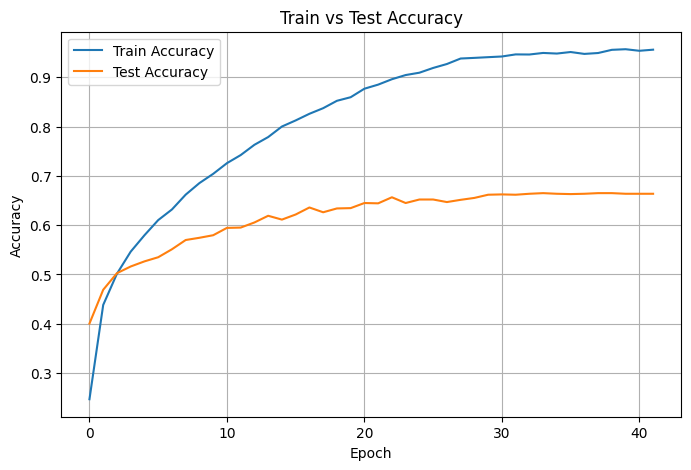

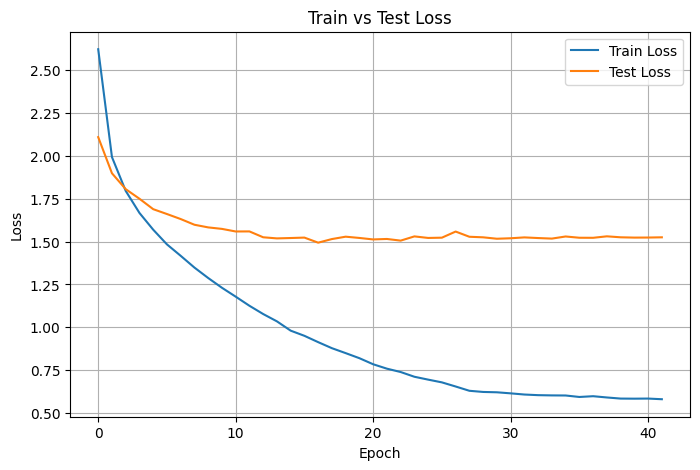

In [23]:
plot_train_test_curves(history)

In [24]:
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 362ms/step - accuracy: 0.6153 - loss: 1.6366
Final test loss: 1.5179
Final test accuracy: 0.6649


In [25]:
train_embed_gen = create_embedding_generator(
    data_dir=train_dir,
    target_size=(224, 224),
    batch_size=32
)

test_embed_gen = create_embedding_generator(
    data_dir=test_dir,
    target_size=(224, 224),
    batch_size=32
)

df_train_embeddings = build_embedding_dataframe(model, train_embed_gen)
df_test_embeddings = build_embedding_dataframe(model, test_embed_gen)

Found 13898 images belonging to 22 classes.
Found 1546 images belonging to 22 classes.
435/435 ━━━━━━━━━━━━━━━━━━━━ 118s 228ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 44s 588ms/step


In [26]:
display(df_train_embeddings.head())
display(df_test_embeddings.head())

,image_path,label,embedding
0,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.134, -0.4631, 0.2327, 0.1227, 0.1617, 0.502..."
1,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.162, -0.3225, -0.321, 0.2356, -0.2229, 0.78..."
2,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[-0.04095, -0.4631, -0.0911, 0.5283, -0.01223,..."
3,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.682, -0.363, 0.294, 0.2184, 0.1169, -0.926,..."
4,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[-0.121, 0.2477, 0.6743, -0.441, 0.927, 1.161,..."


,image_path,label,embedding
0,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.1779, 0.271, 1.725, -0.3052, 0.3865, 0.9404..."
1,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.2201, -0.1516, 0.759, -0.2305, 0.156, 0.297..."
2,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[-0.01428, -0.2747, -0.6035, -0.7793, 0.2297, ..."
3,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.1045, -0.05048, -0.1848, -0.494, 0.1821, 0...."
4,/kaggle/input/datasets/pacificrm/skindiseaseda...,Acne,"[0.2976, 0.501, 0.3713, -0.4678, 0.528, 0.3638..."


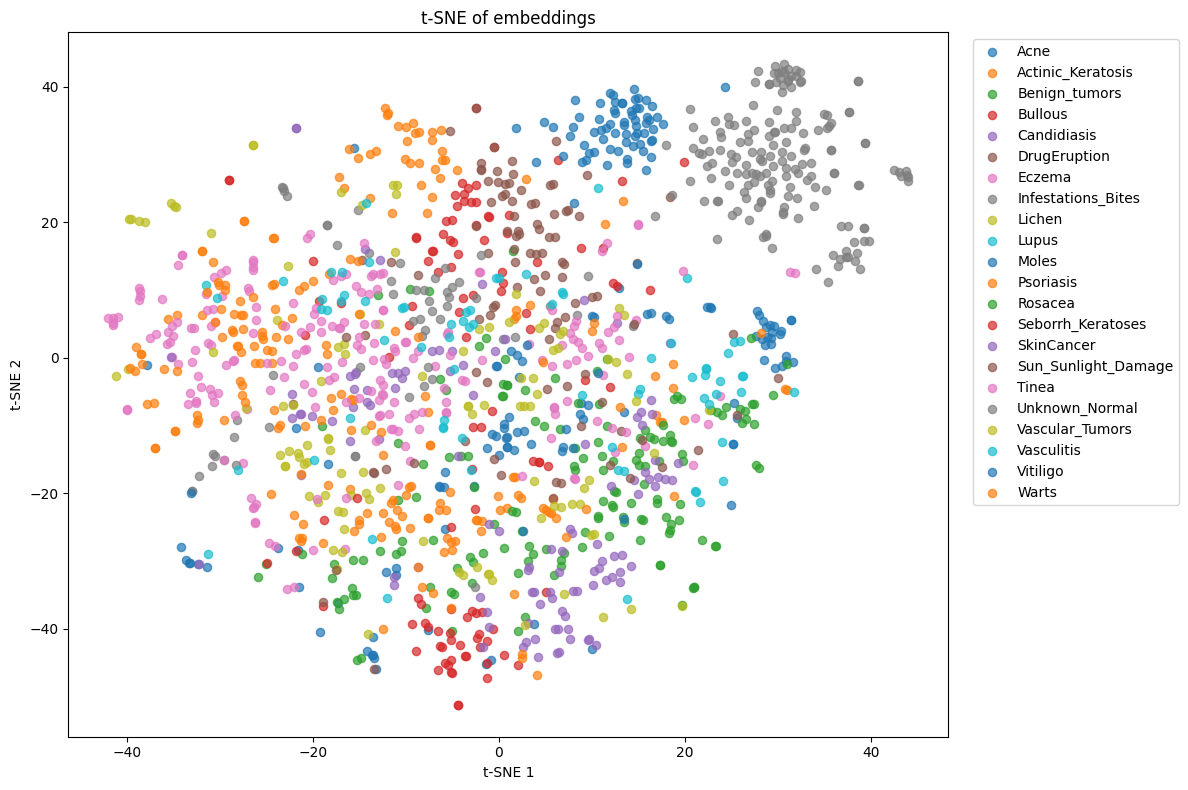

In [27]:
plot_tsne_embeddings(df_train_embeddings, sample_size=1500)

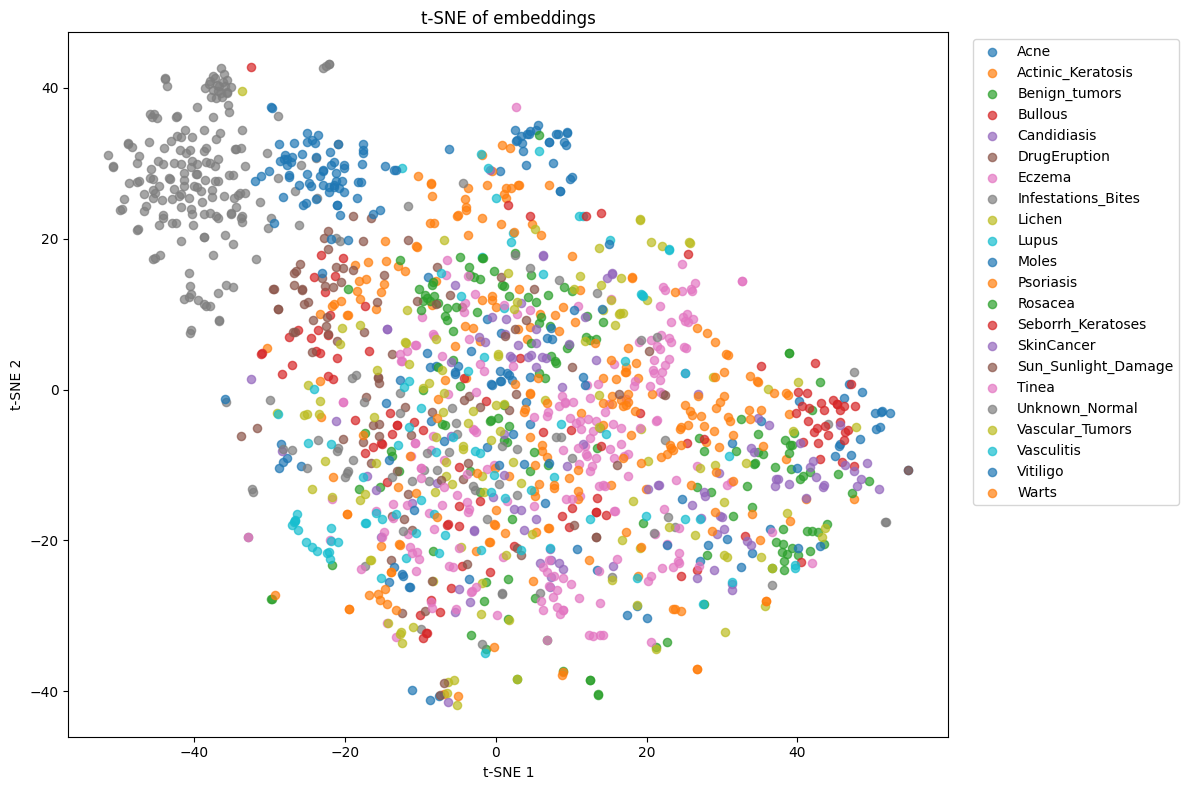

In [28]:
plot_tsne_embeddings(df_test_embeddings)

# Training Classical ML on embedding

In [29]:
df_train_embeddings.to_csv("/kaggle/working/train_embeddings.csv", index=False)
df_test_embeddings.to_csv("/kaggle/working/test_embeddings.csv", index=False)

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [31]:
def train_classical_models_on_embeddings(
    df_train_embeddings,
    df_test_embeddings,
    embedding_col="embedding",
    label_col="label"
):
    X_train = np.vstack(df_train_embeddings[embedding_col].values)
    X_test = np.vstack(df_test_embeddings[embedding_col].values)

    y_train_raw = df_train_embeddings[label_col].values
    y_test_raw = df_test_embeddings[label_col].values

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train_raw)
    y_test = label_encoder.transform(y_test_raw)
    num_classes = len(label_encoder.classes_)

    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, random_state=42))
        ]),
        "SVM Linear": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="linear", random_state=42))
        ]),
        "SVM RBF": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", random_state=42))
        ]),
        "SVM Poly": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="poly", degree=3, random_state=42))
        ]),
        "Random Forest": Pipeline([
            ("clf", RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "Small NN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(128,),
                activation="relu",
                max_iter=100,
                random_state=42
            ))
        ]),
        "XGBoost": Pipeline([
            ("clf", XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=num_classes,
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            ))
        ])
    }
    total_models = len(models)
    progress_marks = [35, 70, 100]
    printed_marks = set()

    results = []
    fitted_models = {}

    for i, (model_name, pipeline) in enumerate(models.items(), start=1):
        pipeline.fit(X_train, y_train)
        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        test_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
        test_precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
        test_recall = recall_score(y_test, y_test_pred, average="macro", zero_division=0)

        results.append({
            "model_name": model_name,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "f1_score": test_f1,
            "precision": test_precision,
            "recall": test_recall
        })
        fitted_models[model_name] = pipeline
        progress_percent = int((i / total_models) * 100)
        for mark in progress_marks:
            if progress_percent >= mark and mark not in printed_marks:
                print(f"{mark}% done", flush=True)
                printed_marks.add(mark)

    results_df = pd.DataFrame(results).sort_values(
        by="test_accuracy",
        ascending=False
    ).reset_index(drop=True)
    return results_df, fitted_models, label_encoder

In [32]:
def parse_embedding(x):
    x = str(x).strip()
    if x.startswith("[") and x.endswith("]"):
        x_clean = x[1:-1].replace(",", " ")
        return np.fromstring(x_clean, sep=" ", dtype=np.float32)
    return np.array(ast.literal_eval(x), dtype=np.float32)

df_train_embeddings = pd.read_csv("/kaggle/working/train_embeddings.csv")
df_test_embeddings = pd.read_csv("/kaggle/working/test_embeddings.csv")

df_train_embeddings["embedding"] = df_train_embeddings["embedding"].apply(parse_embedding)
df_test_embeddings["embedding"] = df_test_embeddings["embedding"].apply(parse_embedding)

results_df, fitted_models, label_encoder = train_classical_models_on_embeddings(
    df_train_embeddings=df_train_embeddings,
    df_test_embeddings=df_test_embeddings,
    embedding_col="embedding",
    label_col="label"
)

display(results_df)

35% done
70% done
100% done


,model_name,train_accuracy,test_accuracy,f1_score,precision,recall
0,SVM RBF,0.986185,0.712160,0.679177,0.689808,0.673778
1,SVM Poly,0.971435,0.692109,0.653598,0.740074,0.620220
2,SVM Linear,0.997769,0.691462,0.654974,0.659105,0.654805
3,Small NN,0.997626,0.688875,0.649384,0.650617,0.651350
4,XGBoost,0.997769,0.683053,0.651448,0.675170,0.638043
5,Logistic Regression,0.997769,0.674644,0.632032,0.631525,0.634860
6,Random Forest,0.997769,0.635188,0.583662,0.719343,0.552480


In [33]:
df_vit_train_embeddings.to_csv("/kaggle/working/vit_train_embeddings.csv", index=False)
df_vit_test_embeddings.to_csv("/kaggle/working/vit_test_embeddings.csv", index=False)

vit_results_df, vit_fitted_models, vit_label_encoder = train_classical_models_on_embeddings(
    df_train_embeddings=df_vit_train_embeddings,
    df_test_embeddings=df_vit_test_embeddings,
    embedding_col="embedding",
    label_col="label"
)

display(vit_results_df)

35% done
70% done
100% done


,model_name,train_accuracy,test_accuracy,f1_score,precision,recall
0,SVM RBF,0.996834,0.826003,0.798189,0.803385,0.795033
1,SVM Linear,0.997698,0.824709,0.797949,0.803682,0.794357
2,Logistic Regression,0.997626,0.818887,0.791578,0.793220,0.791481
3,SVM Poly,0.996834,0.807891,0.789174,0.816725,0.771748
4,Small NN,0.996978,0.807245,0.778122,0.784128,0.775144
5,Random Forest,0.997769,0.800776,0.775212,0.795714,0.763341
6,XGBoost,0.997769,0.800776,0.774660,0.783778,0.768126
